<a href="https://colab.research.google.com/github/DaverSVK/Spirgonometria/blob/main/Spirgonometria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Unzip to work wirth dataset

# Spiroergometry VT1 / VT2 Simple ML Training

This Google Colab notebook trains a simple machine-learning model to predict expert-defined **VT1** and **VT2** heart-rate values from spiroergometry CSV files.

Expected files:

- `Dataset_Spiroergometria_Labels_Only_Important.xlsx`
- `Pnoe_1.csv`
- `Pnoe_2.csv`
- `Pnoe_3.csv`
- etc.

The model uses 5 main curves:

- HR
- VO2
- VCO2
- RER
- VE

It converts each curve into statistical features and trains a simple `RandomForestRegressor`.


In [ ]:
# Run this in Google Colab.
!pip -q install openpyxl scikit-learn joblib

## 1. Upload files

Upload the Excel label file and all `Pnoe_*.csv` files when prompted.

For larger datasets, you can alternatively mount Google Drive and set `DATA_DIR` to your folder.

In [9]:
from pathlib import Path

USE_GOOGLE_DRIVE = False

if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = Path('/content/drive/MyDrive/spiroergometry_data')
else:
    from google.colab import files
    uploaded = files.upload()
    sample_dir = Path('/content')
    zips = list(sample_dir.glob('*.zip'))

    if zips:
        zip_path = zips[0]
        extract_dir = Path("/content/Dataset")
        extract_dir.mkdir(parents=True, exist_ok=True)

        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_dir)
        print(f"Extracted {zip_path.name} to {extract_dir}")

        # List the first level of extraction to help find the Excel file
        print("Contents after extraction:")
        print(os.listdir(extract_dir))
    else:
        print("Error: No ZIP file found in /content. Please upload the dataset.")
    DATA_DIR = Path('/content/Dataset/Dataset_Spiroergometria')

print("DATA_DIR:", DATA_DIR)
print("Files found:")
for p in sorted(DATA_DIR.glob("*")):
    if p.suffix.lower() in [".xlsx", ".csv"]:
        print(" -", p.name)

Extracted Dataset_Spiroergometria-20260428T171110Z-3-001.zip to /content/Dataset
Contents after extraction:
['Dataset_Spiroergometria']
DATA_DIR: /content/Dataset/Dataset_Spiroergometria
Files found:
 - Dataset_Spiroergometria_Labels.xlsx
 - Dataset_Spiroergometria_Labels_Only_Important.xlsx
 - Pnoe_1.csv
 - Pnoe_10.csv
 - Pnoe_11.csv
 - Pnoe_12.csv
 - Pnoe_13.csv
 - Pnoe_14.csv
 - Pnoe_15.csv
 - Pnoe_16.csv
 - Pnoe_17.csv
 - Pnoe_18.csv
 - Pnoe_19.csv
 - Pnoe_2.csv
 - Pnoe_20.csv
 - Pnoe_21.csv
 - Pnoe_22.csv
 - Pnoe_23.csv
 - Pnoe_24.csv
 - Pnoe_25.csv
 - Pnoe_26_1.csv
 - Pnoe_26_10.csv
 - Pnoe_26_11.csv
 - Pnoe_26_12.csv
 - Pnoe_26_2.csv
 - Pnoe_26_3.csv
 - Pnoe_26_4.csv
 - Pnoe_26_5.csv
 - Pnoe_26_6.csv
 - Pnoe_26_7.csv
 - Pnoe_26_8.csv
 - Pnoe_26_9.csv
 - Pnoe_3.csv
 - Pnoe_4.csv
 - Pnoe_5.csv
 - Pnoe_6.csv
 - Pnoe_7.csv
 - Pnoe_8.csv
 - Pnoe_9.csv


## 2. Imports and configuration

In [10]:
import re
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, KFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

LABEL_FILE = DATA_DIR / "Dataset_Spiroergometria_Labels_Only_Important.xlsx"

# Main 5 signals used for graphs and feature extraction.
SIGNAL_COLS = ["HR", "VO2", "VCO2", "RER", "VE"]

# Optional signals. Used only if available.
OPTIONAL_COLS = ["VT", "BF", "FAT_pct", "CARBS_pct", "MET", "Speed", "Watts"]

RANDOM_STATE = 42

## 3. Load expert labels

The Excel table should contain at least:

- file name column: `Súbor`
- target columns: `VT1 (bpm)`, `VT2 (bpm)`

The code is tolerant to small differences in column names.

In [11]:
def normalize_text(x):
    return str(x).strip().lower()

def find_column(columns, patterns):
    normalized = {col: normalize_text(col) for col in columns}
    for pattern in patterns:
        rx = re.compile(pattern, flags=re.IGNORECASE)
        for original, norm in normalized.items():
            if rx.search(norm):
                return original
    raise ValueError(f"Could not find column matching {patterns}. Available columns: {list(columns)}")

def load_labels(path):
    labels = pd.read_excel(path)
    labels.columns = [str(c).strip() for c in labels.columns]

    file_col = find_column(labels.columns, [r"^súbor$", r"^subor$", r"file", r"csv"])
    vt1_col = find_column(labels.columns, [r"vt1"])
    vt2_col = find_column(labels.columns, [r"vt2"])
    subj_col = None

    try:
        subj_col = find_column(labels.columns, [r"subjekt", r"subject"])
    except Exception:
        pass

    keep = [file_col, vt1_col, vt2_col]
    if subj_col:
        keep = [subj_col] + keep

    labels = labels[keep].copy()
    rename = {file_col: "file", vt1_col: "VT1", vt2_col: "VT2"}
    if subj_col:
        rename[subj_col] = "subject"

    labels = labels.rename(columns=rename)
    labels["file"] = labels["file"].astype(str).str.strip()
    labels["VT1"] = pd.to_numeric(labels["VT1"], errors="coerce")
    labels["VT2"] = pd.to_numeric(labels["VT2"], errors="coerce")
    labels = labels.dropna(subset=["file", "VT1", "VT2"]).reset_index(drop=True)

    return labels

labels = load_labels(LABEL_FILE)
display(labels.head())
print("Number of label rows:", len(labels))

,subject,file,VT1,VT2
0,1,Pnoe_1.csv,132,180
1,2,Pnoe_2.csv,145,184
2,3,Pnoe_3.csv,144,189
3,4,Pnoe_4.csv,149,183
4,5,Pnoe_5.csv,130,177


Number of label rows: 37


## 4. Load and clean one CSV file

In [12]:
def load_spiro_csv(path):
    # Your files use semicolon separators.
    df = pd.read_csv(path, sep=";", encoding="utf-8-sig")

    # Clean column names.
    df.columns = [str(c).strip() for c in df.columns]

    # Mapping from original names to short names.
    rename_map = {
        "T(sec)": "time",
        "HR(bpm)": "HR",
        "VO2(ml/min)": "VO2",
        "VCO2(ml/min)": "VCO2",
        "RER": "RER",
        "VE(l/min)": "VE",
        "VT(l)": "VT",
        "BF(bpm)": "BF",
        "FAT(%)": "FAT_pct",
        "CARBS(%)": "CARBS_pct",
        "MET": "MET",
        "Speed": "Speed",
        "Watts": "Watts",
        "PHASE": "PHASE",
    }

    available_map = {k: v for k, v in rename_map.items() if k in df.columns}
    df = df.rename(columns=available_map)

    required = ["time"] + SIGNAL_COLS
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{path.name}: missing required columns {missing}")

    cols = ["time", "PHASE"] + SIGNAL_COLS + [c for c in OPTIONAL_COLS if c in df.columns]
    cols = [c for c in cols if c in df.columns]
    df = df[cols].copy()

    # Convert numeric columns.
    for c in df.columns:
        if c != "PHASE":
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=["time", "HR", "VO2", "VCO2", "RER", "VE"])

    # Basic physiological sanity filters.
    df = df[(df["HR"] >= 40) & (df["HR"] <= 240)]
    df = df[(df["VO2"] > 0) & (df["VCO2"] > 0) & (df["VE"] > 0)]
    df = df.sort_values("time").drop_duplicates("time")

    # Smooth the 5 main curves slightly.
    for c in SIGNAL_COLS:
        df[c] = df[c].rolling(window=5, center=True, min_periods=1).median()

    return df.reset_index(drop=True)

# Test with the first available CSV.
csv_files = sorted(DATA_DIR.glob("Pnoe_*.csv"))
print("CSV files found:", [p.name for p in csv_files[:10]])

if csv_files:
    test_df = load_spiro_csv(csv_files[0])
    display(test_df.head())
    print(test_df.shape)

CSV files found: ['Pnoe_1.csv', 'Pnoe_10.csv', 'Pnoe_11.csv', 'Pnoe_12.csv', 'Pnoe_13.csv', 'Pnoe_14.csv', 'Pnoe_15.csv', 'Pnoe_16.csv', 'Pnoe_17.csv', 'Pnoe_18.csv']


,time,PHASE,HR,VO2,VCO2,RER,VE,VT,BF,FAT_pct,CARBS_pct,MET,Speed,Watts
0,4.0,NaN,74.0,563.87,515.61,0.88,19.50,0.92,22.16,0.00,0.00,2.72,0.0,0.0
1,9.0,NaN,74.0,554.22,496.19,0.89,19.48,0.83,23.60,41.50,58.50,2.22,0.0,0.0
2,15.0,NaN,74.0,544.57,476.77,0.90,19.46,0.92,21.24,28.53,71.47,2.30,0.0,0.0
3,20.0,NaN,74.0,417.13,375.53,0.91,15.80,0.75,21.01,33.24,66.76,1.70,0.0,0.0
4,24.0,NaN,71.0,323.88,298.25,0.92,13.39,0.80,16.72,26.38,73.62,1.32,0.0,0.0


(204, 14)


## 5. Plot 5 important curves for one subject

The vertical lines show expert VT1 and VT2 as heart-rate levels.  
Because VT1/VT2 are given in bpm, the lines are drawn at the first time where HR is closest to VT1/VT2.

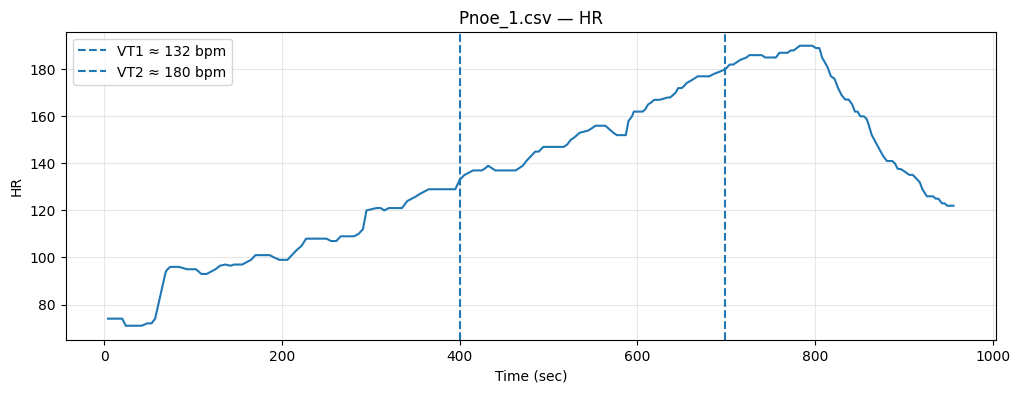

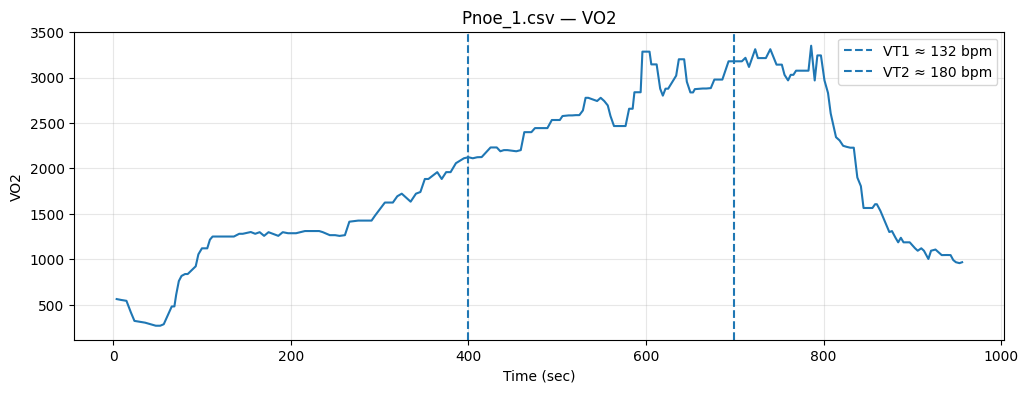

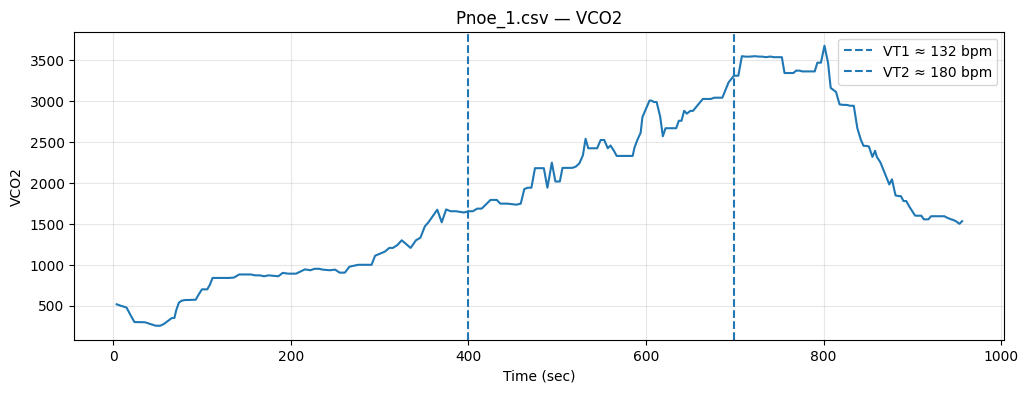

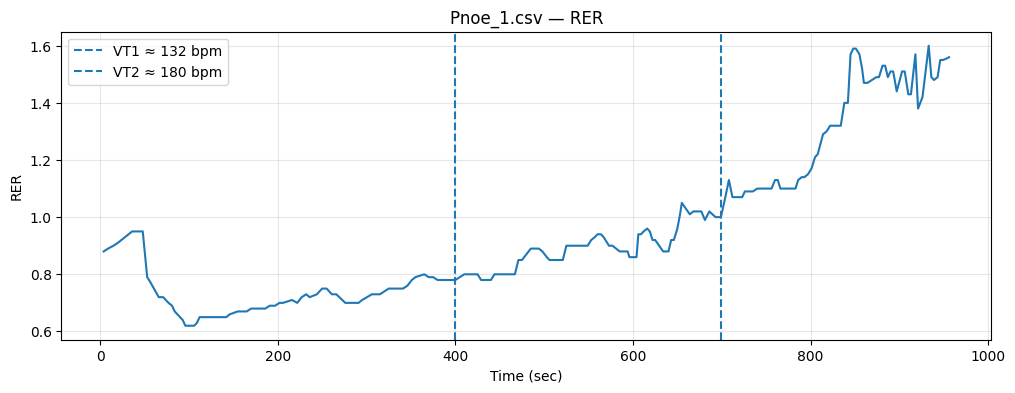

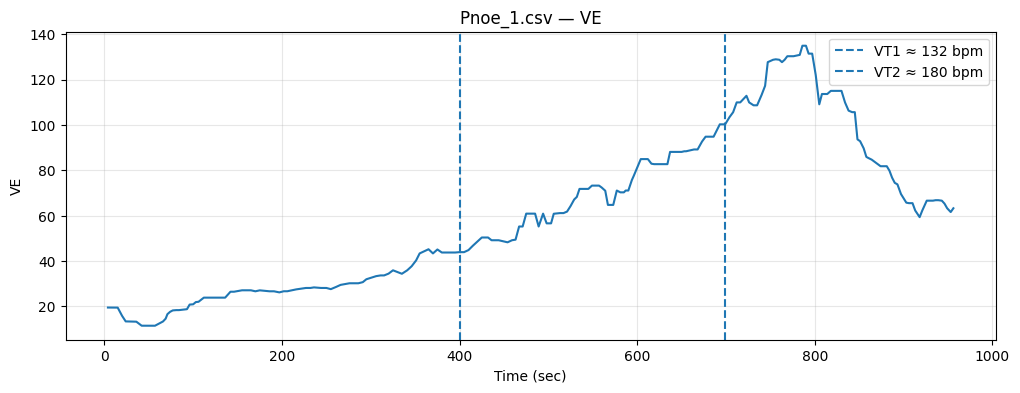

In [14]:
def time_at_closest_hr(df, target_hr):
    idx = (df["HR"] - target_hr).abs().idxmin()
    return float(df.loc[idx, "time"])

def first_time_at_or_above_hr(df, target_hr):
    hits = df.loc[df["HR"] >= target_hr]

    if hits.empty:
        # fallback: closest HR if threshold is never reached
        idx = (df["HR"] - target_hr).abs().idxmin()
        return float(df.loc[idx, "time"])

    return float(hits.iloc[0]["time"])
def plot_subject_curves(file_name, labels_df):
    path = DATA_DIR / file_name
    df = load_spiro_csv(path)

    row = labels_df.loc[labels_df["file"] == file_name].iloc[0]
    vt1 = float(row["VT1"])
    vt2 = float(row["VT2"])

    t_vt1 = first_time_at_or_above_hr(df, vt1)
    t_vt2 = first_time_at_or_above_hr(df, vt2)

    for col in SIGNAL_COLS:
        plt.figure(figsize=(12, 4))
        plt.plot(df["time"], df[col], linewidth=1.5)
        plt.axvline(t_vt1, linestyle="--", label=f"VT1 ≈ {vt1:.0f} bpm")
        plt.axvline(t_vt2, linestyle="--", label=f"VT2 ≈ {vt2:.0f} bpm")
        plt.title(f"{file_name} — {col}")
        plt.xlabel("Time (sec)")
        plt.ylabel(col)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

if len(labels) > 0:
    first_file = labels.iloc[0]["file"]
    if (DATA_DIR / first_file).exists():
        plot_subject_curves(first_file, labels)
    else:
        print(f"{first_file} not uploaded yet.")

## 6. Feature extraction

This turns each full spiroergometry record into one row of ML features.

For every signal, it calculates:

- mean
- standard deviation
- minimum / maximum
- quartiles
- slope over time
- early/middle/late averages
- values near VT1 and VT2 heart rates

This is better for small datasets than a neural network.

In [15]:
def safe_slope(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return np.nan
    x = x[mask]
    y = y[mask]
    if np.std(x) == 0:
        return np.nan
    return np.polyfit(x, y, 1)[0]

def add_signal_features(features, df, col):
    values = df[col].astype(float).values
    time = df["time"].astype(float).values

    features[f"{col}_mean"] = np.nanmean(values)
    features[f"{col}_std"] = np.nanstd(values)
    features[f"{col}_min"] = np.nanmin(values)
    features[f"{col}_max"] = np.nanmax(values)
    features[f"{col}_range"] = np.nanmax(values) - np.nanmin(values)

    for q in [10, 25, 50, 75, 90]:
        features[f"{col}_q{q}"] = np.nanpercentile(values, q)

    features[f"{col}_slope"] = safe_slope(time, values)

    n = len(df)
    if n >= 9:
        early = values[: n // 3]
        middle = values[n // 3 : 2 * n // 3]
        late = values[2 * n // 3 :]
        features[f"{col}_early_mean"] = np.nanmean(early)
        features[f"{col}_middle_mean"] = np.nanmean(middle)
        features[f"{col}_late_mean"] = np.nanmean(late)
        features[f"{col}_late_minus_early"] = np.nanmean(late) - np.nanmean(early)

def add_hr_neighborhood_features(features, df, target_hr, prefix):
    idx = int((df["HR"] - target_hr).abs().idxmin())
    lo = max(0, idx - 5)
    hi = min(len(df), idx + 6)
    window = df.iloc[lo:hi]

    features[f"{prefix}_time"] = float(df.loc[idx, "time"])
    features[f"{prefix}_hr_actual"] = float(df.loc[idx, "HR"])

    for col in SIGNAL_COLS:
        features[f"{prefix}_{col}"] = float(df.loc[idx, col])
        features[f"{prefix}_{col}_window_mean"] = float(window[col].mean())

def extract_features_for_subject(csv_path, vt1=None, vt2=None):
    df = load_spiro_csv(csv_path)
    features = {}

    features["n_points"] = len(df)
    features["duration_sec"] = float(df["time"].max() - df["time"].min())

    for col in SIGNAL_COLS:
        add_signal_features(features, df, col)

    for col in OPTIONAL_COLS:
        if col in df.columns:
            add_signal_features(features, df, col)

    # Some physiologically meaningful derived features.
    features["VO2_per_HR_mean"] = float((df["VO2"] / df["HR"]).replace([np.inf, -np.inf], np.nan).mean())
    features["VCO2_per_VO2_mean"] = float((df["VCO2"] / df["VO2"]).replace([np.inf, -np.inf], np.nan).mean())
    features["VE_per_VO2_mean"] = float((df["VE"] / df["VO2"]).replace([np.inf, -np.inf], np.nan).mean())
    features["VE_per_VCO2_mean"] = float((df["VE"] / df["VCO2"]).replace([np.inf, -np.inf], np.nan).mean())

    # Training-only helper features: values near expert thresholds.
    # For deployment, these must not be used because VT1/VT2 are unknown.
    # So we DO NOT include them in final training by default.
    if vt1 is not None:
        add_hr_neighborhood_features(features, df, vt1, "near_VT1")
    if vt2 is not None:
        add_hr_neighborhood_features(features, df, vt2, "near_VT2")

    return features

def build_dataset(labels_df, use_training_only_neighborhood_features=False):
    rows = []
    targets = []
    used_files = []
    missing_files = []

    for _, row in labels_df.iterrows():
        csv_path = DATA_DIR / row["file"]
        if not csv_path.exists():
            missing_files.append(row["file"])
            continue

        try:
            if use_training_only_neighborhood_features:
                feats = extract_features_for_subject(csv_path, row["VT1"], row["VT2"])
            else:
                feats = extract_features_for_subject(csv_path)

            rows.append(feats)
            targets.append([row["VT1"], row["VT2"]])
            used_files.append(row["file"])
        except Exception as e:
            print(f"Skipping {row['file']}: {e}")

    X = pd.DataFrame(rows)
    X = X.replace([np.inf, -np.inf], np.nan)

    # Fill missing values by column medians.
    X = X.apply(lambda s: s.fillna(s.median()), axis=0)
    X = X.fillna(0)

    y = pd.DataFrame(targets, columns=["VT1", "VT2"])

    return X, y, used_files, missing_files

X, y, used_files, missing_files = build_dataset(labels)

print("Used files:", len(used_files))
print("Missing files:", len(missing_files))
if missing_files:
    print("First missing files:", missing_files[:10])

display(X.head())
display(y.head())
print("X shape:", X.shape)
print("y shape:", y.shape)

Used files: 37
Missing files: 0


,n_points,duration_sec,HR_mean,HR_std,HR_min,HR_max,HR_range,HR_q10,HR_q25,HR_q50,...,Watts_q90,Watts_slope,Watts_early_mean,Watts_middle_mean,Watts_late_mean,Watts_late_minus_early,VO2_per_HR_mean,VCO2_per_VO2_mean,VE_per_VO2_mean,VE_per_VCO2_mean
0,204,952.0,139.077304,32.990985,71.0,190.0,119.0,95.0,109.0,139.000,...,286.900,-0.004936,112.260147,233.863382,106.824265,-5.435882,13.712312,0.976991,0.033210,0.032935
1,253,1132.0,151.183794,30.614601,84.0,195.0,111.0,110.0,123.0,160.000,...,614.160,0.167652,210.076667,444.085833,372.244353,162.167686,19.419792,0.901308,0.029256,0.032147
2,187,1005.0,159.027433,28.115006,99.0,198.0,99.0,116.0,138.5,160.000,...,240.000,0.058894,66.531290,141.774194,120.000000,53.468710,12.715207,0.925864,0.031043,0.033763
3,184,891.0,157.330380,23.733296,108.0,186.0,78.0,123.0,138.0,164.515,...,132.690,-0.053064,85.637377,67.278689,50.564516,-35.072861,10.188450,0.992366,0.038023,0.037866
4,213,982.0,144.107418,31.576576,91.0,186.0,95.0,98.6,110.0,148.000,...,460.396,0.096105,145.038169,332.342394,226.804085,81.765915,11.795388,0.902706,0.030067,0.033045


,VT1,VT2
0,132,180
1,145,184
2,144,189
3,149,183
4,130,177


X shape: (37, 186)
y shape: (37, 2)


## 7. Train and evaluate simple ML models

For small datasets, evaluation uses Leave-One-Out cross-validation.  
For larger datasets, it uses 5-fold cross-validation.

In [16]:
def choose_cv(n):
    if n < 3:
        return None
    if n < 30:
        return LeaveOneOut()
    return KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=10.0))
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=500,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

def evaluate_models(X, y):
    n = len(X)
    cv = choose_cv(n)

    if cv is None:
        print("Not enough subjects for training/evaluation.")
        print("Upload more Pnoe_*.csv files that match rows in the Excel label file.")
        return None, None

    summary = []

    for name, model in models.items():
        pred = cross_val_predict(model, X, y, cv=cv)

        vt1_mae = mean_absolute_error(y["VT1"], pred[:, 0])
        vt2_mae = mean_absolute_error(y["VT2"], pred[:, 1])
        mean_mae = np.mean([vt1_mae, vt2_mae])

        summary.append({
            "model": name,
            "VT1_MAE_bpm": vt1_mae,
            "VT2_MAE_bpm": vt2_mae,
            "Mean_MAE_bpm": mean_mae
        })

    results = pd.DataFrame(summary).sort_values("Mean_MAE_bpm")
    return results, cv

results, cv = evaluate_models(X, y)
if results is not None:
    display(results)

,model,VT1_MAE_bpm,VT2_MAE_bpm,Mean_MAE_bpm
2,ExtraTrees,9.020027,4.607964,6.813995
1,RandomForest,9.881420,4.648446,7.264933
0,Ridge,11.096284,4.775891,7.936088


## 8. Train final model

The best evaluated model is trained on all available subjects.

In [17]:
if results is not None:
    best_name = results.iloc[0]["model"]
    final_model = models[best_name]
    final_model.fit(X, y)

    print("Best model:", best_name)
    print("Training subjects:", len(X))
    print("Training features:", X.shape[1])
else:
    final_model = None
    best_name = None

Best model: ExtraTrees
Training subjects: 37
Training features: 186


## 9. Cross-validated prediction plot

,file,VT1_true,VT1_pred,VT2_true,VT2_pred,VT1_error,VT2_error
0,Pnoe_1.csv,132,127.364000,180,175.825667,-4.636000,-4.174333
1,Pnoe_2.csv,145,150.578000,184,186.396667,5.578000,2.396667
2,Pnoe_3.csv,144,144.483667,189,179.045333,0.483667,-9.954667
3,Pnoe_4.csv,149,144.863000,183,180.287000,-4.137000,-2.713000
4,Pnoe_5.csv,130,144.322333,177,178.980000,14.322333,1.980000
5,Pnoe_6.csv,136,153.751667,190,185.676333,17.751667,-4.323667
6,Pnoe_7.csv,139,139.745667,176,176.957000,0.745667,0.957000
7,Pnoe_8.csv,146,146.919667,180,186.275000,0.919667,6.275000
8,Pnoe_9.csv,170,138.786000,193,178.286333,-31.214000,-14.713667
9,Pnoe_10.csv,129,131.934333,176,177.888333,2.934333,1.888333


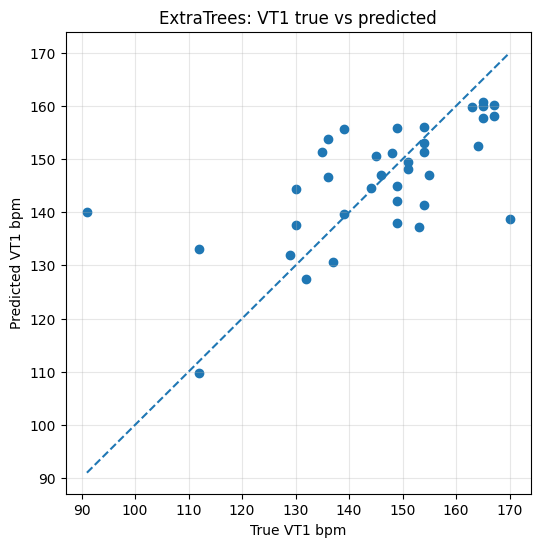

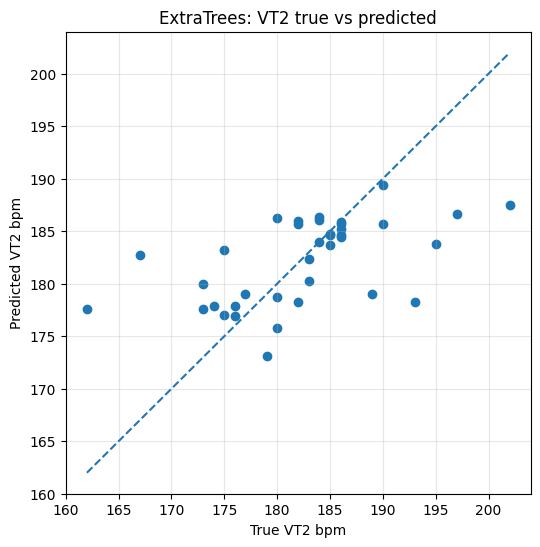

VT1 MAE: 9.020027027027023
VT2 MAE: 4.607963963963978


In [18]:
if results is not None:
    pred = cross_val_predict(models[best_name], X, y, cv=cv)

    pred_df = pd.DataFrame({
        "file": used_files,
        "VT1_true": y["VT1"].values,
        "VT1_pred": pred[:, 0],
        "VT2_true": y["VT2"].values,
        "VT2_pred": pred[:, 1],
    })

    pred_df["VT1_error"] = pred_df["VT1_pred"] - pred_df["VT1_true"]
    pred_df["VT2_error"] = pred_df["VT2_pred"] - pred_df["VT2_true"]

    display(pred_df)

    for target in ["VT1", "VT2"]:
        plt.figure(figsize=(6, 6))
        plt.scatter(pred_df[f"{target}_true"], pred_df[f"{target}_pred"])
        mn = min(pred_df[f"{target}_true"].min(), pred_df[f"{target}_pred"].min())
        mx = max(pred_df[f"{target}_true"].max(), pred_df[f"{target}_pred"].max())
        plt.plot([mn, mx], [mn, mx], linestyle="--")
        plt.xlabel(f"True {target} bpm")
        plt.ylabel(f"Predicted {target} bpm")
        plt.title(f"{best_name}: {target} true vs predicted")
        plt.grid(True, alpha=0.3)
        plt.show()

    print("VT1 MAE:", mean_absolute_error(pred_df["VT1_true"], pred_df["VT1_pred"]))
    print("VT2 MAE:", mean_absolute_error(pred_df["VT2_true"], pred_df["VT2_pred"]))

## 10. Feature importance

For tree models, this shows which extracted features help most.

,feature,importance
8,HR_q25,0.143175
7,HR_q10,0.099939
13,HR_early_mean,0.099384
2,HR_mean,0.069394
12,HR_slope,0.018226
14,HR_middle_mean,0.017535
11,HR_q90,0.015490
1,duration_sec,0.015456
5,HR_max,0.013328
10,HR_q75,0.013014


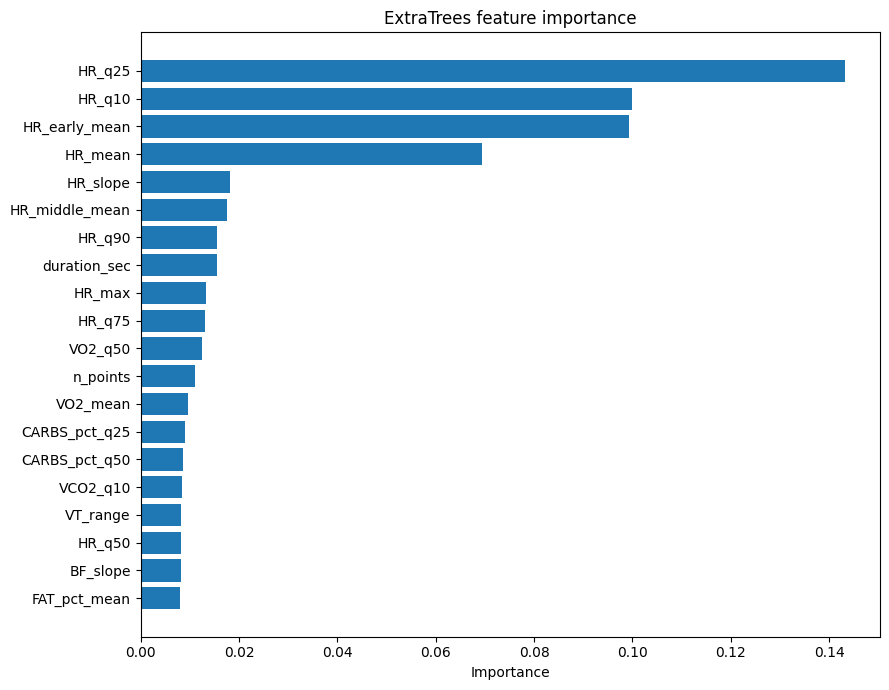

In [ ]:
if final_model is not None and best_name in ["RandomForest", "ExtraTrees"]:
    importances = pd.DataFrame({
        "feature": X.columns,
        "importance": final_model.feature_importances_
    }).sort_values("importance", ascending=False)

    display(importances.head(30))

    top = importances.head(20).iloc[::-1]
    plt.figure(figsize=(9, 7))
    plt.barh(top["feature"], top["importance"])
    plt.title(f"{best_name} feature importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

## 11. Save model

In [ ]:
if final_model is not None:
    bundle = {
        "model": final_model,
        "model_name": best_name,
        "feature_columns": list(X.columns),
        "signal_columns": SIGNAL_COLS,
        "optional_columns": OPTIONAL_COLS,
    }

    model_path = DATA_DIR / "vt1_vt2_simple_ml_model.joblib"
    joblib.dump(bundle, model_path)

    print("Saved model to:", model_path)

    try:
        from google.colab import files
        files.download(str(model_path))
    except Exception:
        pass

Saved model to: /content/sample_data/Dataset/Dataset_Spiroergometria/vt1_vt2_simple_ml_model.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Predict VT1 / VT2 for a new CSV file

In [19]:
def predict_new_csv(csv_path, model_bundle_path=None):
    if model_bundle_path is None:
        model_bundle_path = DATA_DIR / "vt1_vt2_simple_ml_model.joblib"

    bundle = joblib.load(model_bundle_path)
    model = bundle["model"]
    feature_columns = bundle["feature_columns"]

    feats = extract_features_for_subject(Path(csv_path))
    X_new = pd.DataFrame([feats])
    X_new = X_new.replace([np.inf, -np.inf], np.nan)

    # Ensure same columns as training.
    for col in feature_columns:
        if col not in X_new.columns:
            X_new[col] = 0

    X_new = X_new[feature_columns]
    X_new = X_new.fillna(0)

    pred = model.predict(X_new)[0]
    vt1, vt2 = float(pred[0]), float(pred[1])

    return {
        "VT1_pred_bpm": vt1,
        "VT2_pred_bpm": vt2,
        "Zone_1_upper_bpm": vt1,
        "Zone_2_upper_bpm": (vt1 + vt2) / 2,
        "Zone_3_upper_bpm": vt2,
    }

# Example:
predict_new_csv(DATA_DIR / "Pnoe_25.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Dataset/Dataset_Spiroergometria/vt1_vt2_simple_ml_model.joblib'

## 11. Percentage HR set

VT1 ≈ 60–70% of HRmax

VT2 ≈ 80–90% of HRmax

In [29]:
from sklearn.metrics import mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def estimate_vt_from_hrmax(file_name, vt1_pct=0.70, vt2_pct=0.85):
    path = DATA_DIR / file_name
    df = load_spiro_csv(path)

    hrmax = float(df["HR"].max())

    vt1_pred = vt1_pct * hrmax
    vt2_pred = vt2_pct * hrmax

    return hrmax, vt1_pred, vt2_pred

rows = []

for _, row in labels.iterrows():
    file_name = row["file"]
    path = DATA_DIR / file_name

    if not path.exists():
        print(f"Skipping {file_name}: file not uploaded.")
        continue

    try:
        hrmax, vt1_pred, vt2_pred = estimate_vt_from_hrmax(
            file_name,
            vt1_pct=0.70,
            vt2_pct=0.85
        )

        rows.append({
            "file": file_name,
            "HRmax": hrmax,

            "VT1_true": float(row["VT1"]),
            "VT1_predMathematical": vt1_pred,

            "VT2_true": float(row["VT2"]),
            "VT2_predMathematical": vt2_pred,
        })

    except Exception as e:
        print(f"Skipping {file_name}: {e}")

hr_baseline_df = pd.DataFrame(rows)

hr_baseline_df["VT1_error"] = hr_baseline_df["VT1_predMathematical"] - hr_baseline_df["VT1_true"]
hr_baseline_df["VT2_error"] = hr_baseline_df["VT2_predMathematical"] - hr_baseline_df["VT2_true"]

display(hr_baseline_df)

,file,HRmax,VT1_true,VT1_predMathematical,VT2_true,VT2_predMathematical,VT1_error,VT2_error
0,Pnoe_1.csv,190.0,132.0,133.0,180.0,161.50,1.0,-18.50
1,Pnoe_2.csv,195.0,145.0,136.5,184.0,165.75,-8.5,-18.25
2,Pnoe_3.csv,198.0,144.0,138.6,189.0,168.30,-5.4,-20.70
3,Pnoe_4.csv,186.0,149.0,130.2,183.0,158.10,-18.8,-24.90
4,Pnoe_5.csv,186.0,130.0,130.2,177.0,158.10,0.2,-18.90
5,Pnoe_6.csv,199.0,136.0,139.3,190.0,169.15,3.3,-20.85
6,Pnoe_7.csv,184.0,139.0,128.8,176.0,156.40,-10.2,-19.60
7,Pnoe_8.csv,195.0,146.0,136.5,180.0,165.75,-9.5,-14.25
8,Pnoe_9.csv,200.0,170.0,140.0,193.0,170.00,-30.0,-23.00
9,Pnoe_10.csv,182.0,129.0,127.4,176.0,154.70,-1.6,-21.30


HRmax baseline VT1 MAE: 17.86756756756757
HRmax baseline VT2 MAE: 22.663513513513518


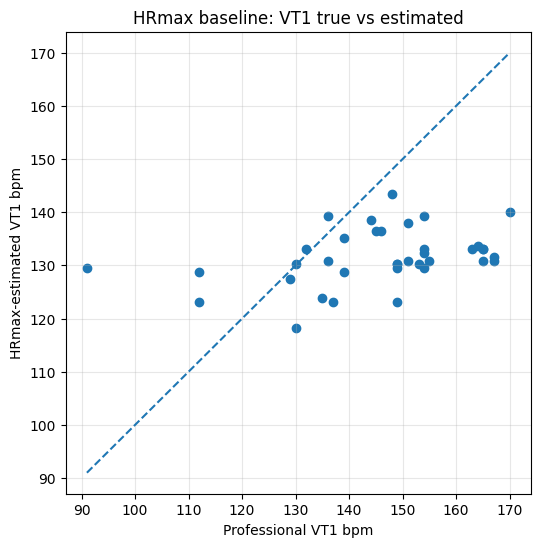

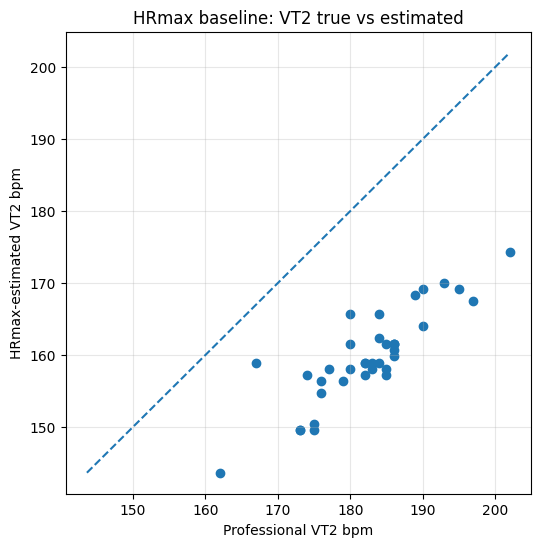

In [27]:
print("HRmax baseline VT1 MAE:", mean_absolute_error(
    hr_baseline_df["VT1_true"],
    hr_baseline_df["VT1_predMathematical"]
))

print("HRmax baseline VT2 MAE:", mean_absolute_error(
    hr_baseline_df["VT2_true"],
    hr_baseline_df["VT2_predMathematical"]
))
for target in ["VT1", "VT2"]:
    plt.figure(figsize=(6, 6))

    plt.scatter(
        hr_baseline_df[f"{target}_true"],
        hr_baseline_df[f"{target}_pred"]
    )

    mn = min(
        hr_baseline_df[f"{target}_true"].min(),
        hr_baseline_df[f"{target}_pred"].min()
    )
    mx = max(
        hr_baseline_df[f"{target}_true"].max(),
        hr_baseline_df[f"{target}_pred"].max()
    )

    plt.plot([mn, mx], [mn, mx], linestyle="--")

    plt.xlabel(f"Professional {target} bpm")
    plt.ylabel(f"HRmax-estimated {target} bpm")
    plt.title(f"HRmax baseline: {target} true vs estimated")
    plt.grid(True, alpha=0.3)
    plt.show()

,method,VT1_MAE,VT2_MAE
0,HRmax mathematical,17.867568,22.663514
1,ExtraTrees,9.020027,4.607964


,file,VT1_true,VT2_true,VT1_ML,VT2_ML,VT1_Mathematical,VT2_Mathematical
0,Pnoe_1.csv,132,180,127.364000,175.825667,133.0,161.50
1,Pnoe_2.csv,145,184,150.578000,186.396667,136.5,165.75
2,Pnoe_3.csv,144,189,144.483667,179.045333,138.6,168.30
3,Pnoe_4.csv,149,183,144.863000,180.287000,130.2,158.10
4,Pnoe_5.csv,130,177,144.322333,178.980000,130.2,158.10


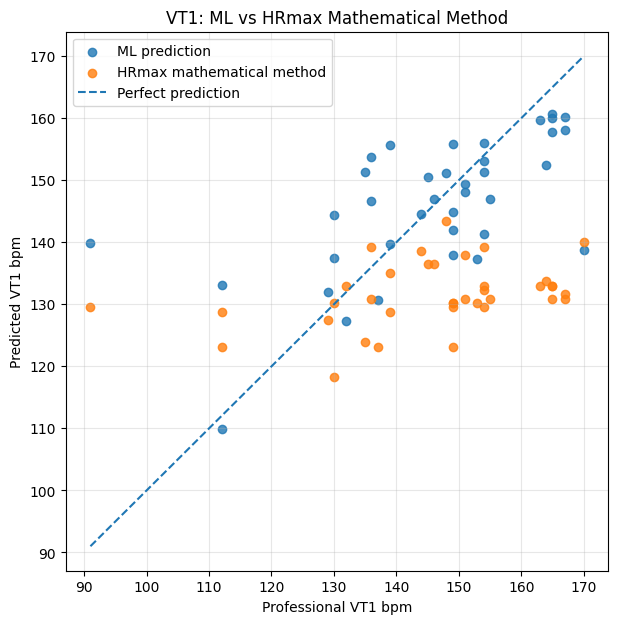

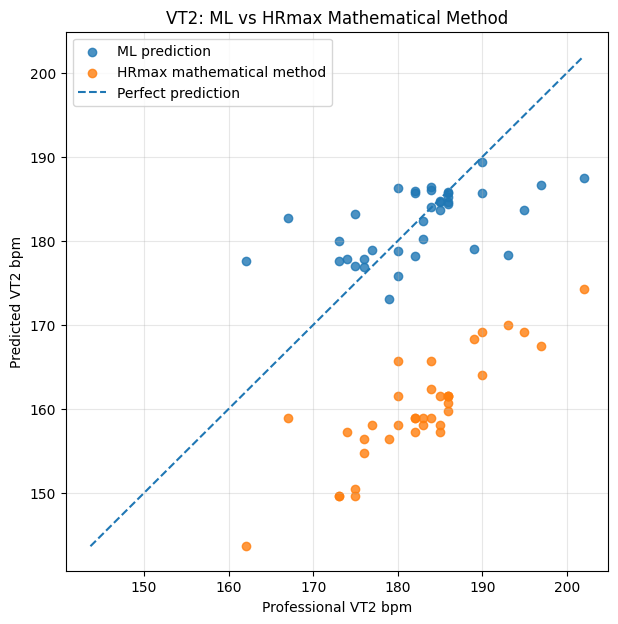

In [32]:
comparison = pd.DataFrame({
    "method": ["HRmax mathematical", best_name],

    "VT1_MAE": [
        mean_absolute_error(
            hr_baseline_df["VT1_true"],
            hr_baseline_df["VT1_predMathematical"]
        ),
        mean_absolute_error(
            pred_df["VT1_true"],
            pred_df["VT1_pred"]
        ),
    ],

    "VT2_MAE": [
        mean_absolute_error(
            hr_baseline_df["VT2_true"],
            hr_baseline_df["VT2_predMathematical"]
        ),
        mean_absolute_error(
            pred_df["VT2_true"],
            pred_df["VT2_pred"]
        ),
    ],
})

display(comparison)
compare_df = pred_df[[
    "file",
    "VT1_true",
    "VT2_true",
    "VT1_pred",
    "VT2_pred"
]].merge(
    hr_baseline_df[[
        "file",
        "VT1_predMathematical",
        "VT2_predMathematical"
    ]],
    on="file",
    how="inner"
)

compare_df = compare_df.rename(columns={
    "VT1_pred": "VT1_ML",
    "VT2_pred": "VT2_ML",
    "VT1_predMathematical": "VT1_Mathematical",
    "VT2_predMathematical": "VT2_Mathematical",
})

display(compare_df.head())
for target in ["VT1", "VT2"]:
    plt.figure(figsize=(7, 7))

    plt.scatter(
        compare_df[f"{target}_true"],
        compare_df[f"{target}_ML"],
        label="ML prediction",
        alpha=0.8
    )

    plt.scatter(
        compare_df[f"{target}_true"],
        compare_df[f"{target}_Mathematical"],
        label="HRmax mathematical method",
        alpha=0.8
    )

    mn = min(
        compare_df[f"{target}_true"].min(),
        compare_df[f"{target}_ML"].min(),
        compare_df[f"{target}_Mathematical"].min()
    )

    mx = max(
        compare_df[f"{target}_true"].max(),
        compare_df[f"{target}_ML"].max(),
        compare_df[f"{target}_Mathematical"].max()
    )

    plt.plot([mn, mx], [mn, mx], linestyle="--", label="Perfect prediction")

    plt.xlabel(f"Professional {target} bpm")
    plt.ylabel(f"Predicted {target} bpm")
    plt.title(f"{target}: ML vs HRmax Mathematical Method")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()